In [1]:
#import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv(r"C:\Users\cradr\Downloads\Dataset.csv")                                                    

In [2]:
#A sneak peak of the table
df.head()


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
#Understand data structures and Identify the string formats to be converted to date formats
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 686.8 KB


In [4]:
#Check for Null values
df.isnull().sum

<bound method DataFrame.sum of       show_id   type  title  director  country  date_added  release_year  \
0       False  False  False     False    False       False         False   
1       False  False  False     False    False       False         False   
2       False  False  False     False    False       False         False   
3       False  False  False     False    False       False         False   
4       False  False  False     False    False       False         False   
...       ...    ...    ...       ...      ...         ...           ...   
8785    False  False  False     False    False       False         False   
8786    False  False  False     False    False       False         False   
8787    False  False  False     False    False       False         False   
8788    False  False  False     False    False       False         False   
8789    False  False  False     False    False       False         False   

      rating  duration  listed_in  
0      False     Fal

In [5]:
#Change str to date-time datatype format
df['date_added']= pd.to_datetime(df['date_added'])

In [6]:
#df['release_year'] = pd.to_datetime(df['release_year'])

In [7]:
#Standardize duration column, create two more rows, duration type and duration number
df['duration_num'] = df['duration'].str.extract (r'(\d+)').astype(float)


In [8]:
df['duration_time'] = df['duration'].str.extract('([a-zA-Z]+)')

In [9]:
df[['duration','duration_time','duration_num']].head()

,duration,duration_time,duration_num
0,90 min,min,90.0
1,1 Season,Season,1.0
2,1 Season,Season,1.0
3,91 min,min,91.0
4,125 min,min,125.0


In [10]:
#Check for duplicates and inconsistensies
df.duplicated().sum()

np.int64(0)

In [11]:
df['country'].unique()
df['rating'].unique()
df['type'].unique()
df['country'].unique()
df['rating'].unique()
df['title'].unique()
df['director'].unique()

<StringArray>
[        'Kirsten Johnson',         'Julien Leclercq',
           'Mike Flanagan',           'Bruno Garotti',
            'Haile Gerima',         'Andy Devonshire',
          'Theodore Melfi',             'Suhas Kadav',
     'Christian Schwochow',               'Not Given',
 ...
 'Saratswadee Wongsomphet',       'Kirati Nakintanon',
             'Mark Risley',             'James Brown',
              'Ivona Juka',                  'Mu Chu',
 'Chandra Prakash Dwivedi',         'Majid Al Ansari',
            'Peter Hewitt',             'Mozez Singh']
Length: 4528, dtype: str

In [12]:
df['country'].unique()

<StringArray>
[       'United States',               'France',               'Brazil',
       'United Kingdom',                'India',              'Germany',
             'Pakistan',            'Not Given',                'China',
         'South Africa',                'Japan',              'Nigeria',
                'Spain',          'Philippines',            'Australia',
            'Argentina',               'Canada',            'Hong Kong',
                'Italy',          'New Zealand',                'Egypt',
             'Colombia',               'Mexico',              'Belgium',
          'Switzerland',               'Taiwan',             'Bulgaria',
               'Poland',          'South Korea',         'Saudi Arabia',
             'Thailand',            'Indonesia',               'Kuwait',
             'Malaysia',              'Vietnam',              'Lebanon',
              'Romania',                'Syria', 'United Arab Emirates',
               'Sweden',            '

In [13]:
df['listed_in'].unique()

<StringArray>
[                                                'Documentaries',
 'Crime TV Shows, International TV Shows, TV Action & Adventure',
                            'TV Dramas, TV Horror, TV Mysteries',
                            'Children & Family Movies, Comedies',
              'Dramas, Independent Movies, International Movies',
                                  'British TV Shows, Reality TV',
                                              'Comedies, Dramas',
          'Children & Family Movies, Comedies, Music & Musicals',
                                  'Dramas, International Movies',
                    'Children & Family Movies, Music & Musicals',
 ...
                      'British TV Shows, Docuseries, Reality TV',
                    'Anime Series, Crime TV Shows, TV Thrillers',
        'Classic & Cult TV, Kids' TV, Spanish-Language TV Shows',
       'Romantic TV Shows, Spanish-Language TV Shows, TV Dramas',
                            'TV Action & Adventure, TV Co

In [14]:
df['director'].unique()

<StringArray>
[        'Kirsten Johnson',         'Julien Leclercq',
           'Mike Flanagan',           'Bruno Garotti',
            'Haile Gerima',         'Andy Devonshire',
          'Theodore Melfi',             'Suhas Kadav',
     'Christian Schwochow',               'Not Given',
 ...
 'Saratswadee Wongsomphet',       'Kirati Nakintanon',
             'Mark Risley',             'James Brown',
              'Ivona Juka',                  'Mu Chu',
 'Chandra Prakash Dwivedi',         'Majid Al Ansari',
            'Peter Hewitt',             'Mozez Singh']
Length: 4528, dtype: str

In [15]:
df['rating']= df['rating'].replace({'UR':'NR'})

In [16]:
df_genre= df.assign(listed_in =df['listed_in'].str.split(',')).explode('listed_in')

In [17]:
df_genre[['listed_in','title']].head(10)

,listed_in,title
0,Documentaries,Dick Johnson Is Dead
1,Crime TV Shows,Ganglands
1,International TV Shows,Ganglands
1,TV Action & Adventure,Ganglands
2,TV Dramas,Midnight Mass
2,TV Horror,Midnight Mass
2,TV Mysteries,Midnight Mass
3,Children & Family Movies,Confessions of an Invisible Girl
3,Comedies,Confessions of an Invisible Girl
4,Dramas,Sankofa


In [18]:
df.to_csv('netflix_cleaned.csv',index=False)

In [19]:
df_genre.to_csv('netflix_genres_exploded.csv', index=False)

In [20]:
import os
print (os.listdir())

['03-vizwhiz-0 R.htm', '05-visualisation-ggplot2.html', '0cvJS5ocTSu-77CVZvn6kw_55078d160a924e49aca0837f03d995f1_Lauren-s-Furniture-Store-Transaction-Table.csv', '100+Days+of+Python+Check+Off+Posters.pdf', '106 PIL template.docx', '10Alytics Dashboard (1).xlsx', '10Alytics Dashboard (2).xlsx', '10Alytics Dashboard.xlsx', '10ALYTICS Excel material In use.xlsx', '12+Rules+to+Learn+to+Code+eBook-Copyright+App+Brewery.pdf', '17720.jpg', '1bg1yc_bTtiWMOK9yT-2GA_34bc081e5ac4493cbce79de59cb14ee1_Population-Latin-and-Caribbean-Countries-2010-2019.xlsx', '201057987-Quick-list-of-useful-R-packages.htm', '2026-07-11-medication-administration-online-Ezeadigwu.pdf', '20260717094252.pdf', '2197a02e-ddbf-4b22-86b7-93668ca37a81-Cynthia_RACI-Matrix_Blush_and_Bloom_-_ (1).xlsx', '2197a02e-ddbf-4b22-86b7-93668ca37a81-Cynthia_RACI-Matrix_Blush_and_Bloom_-_.xlsx', '233-add-annotations-on-ggplot2-chart.html', '25 best data visualization.htm', '28032025084847514202503280838000024ZHR.pdf', '28701.jpg', '2kdGw

In [21]:
import pandas as pd

In [22]:
import os
os.listdir()

['03-vizwhiz-0 R.htm',
 '05-visualisation-ggplot2.html',
 '0cvJS5ocTSu-77CVZvn6kw_55078d160a924e49aca0837f03d995f1_Lauren-s-Furniture-Store-Transaction-Table.csv',
 '100+Days+of+Python+Check+Off+Posters.pdf',
 '106 PIL template.docx',
 '10Alytics Dashboard (1).xlsx',
 '10Alytics Dashboard (2).xlsx',
 '10Alytics Dashboard.xlsx',
 '10ALYTICS Excel material In use.xlsx',
 '12+Rules+to+Learn+to+Code+eBook-Copyright+App+Brewery.pdf',
 '17720.jpg',
 '1bg1yc_bTtiWMOK9yT-2GA_34bc081e5ac4493cbce79de59cb14ee1_Population-Latin-and-Caribbean-Countries-2010-2019.xlsx',
 '201057987-Quick-list-of-useful-R-packages.htm',
 '2026-07-11-medication-administration-online-Ezeadigwu.pdf',
 '20260717094252.pdf',
 '2197a02e-ddbf-4b22-86b7-93668ca37a81-Cynthia_RACI-Matrix_Blush_and_Bloom_-_ (1).xlsx',
 '2197a02e-ddbf-4b22-86b7-93668ca37a81-Cynthia_RACI-Matrix_Blush_and_Bloom_-_.xlsx',
 '233-add-annotations-on-ggplot2-chart.html',
 '25 best data visualization.htm',
 '28032025084847514202503280838000024ZHR.pdf',


In [28]:
'netflix_cleaned.csv' in os.listdir()

True

In [ ]:
#Task 2: Load cleaned data sets
import pandas as pd
df=pd.read_csv('netflix_cleaned.csv')
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_num,duration_time
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90.0,min
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1.0,Season
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1.0,Season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91.0,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125.0,min


In [ ]:
#Calculate total number of TV shows and Movies
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

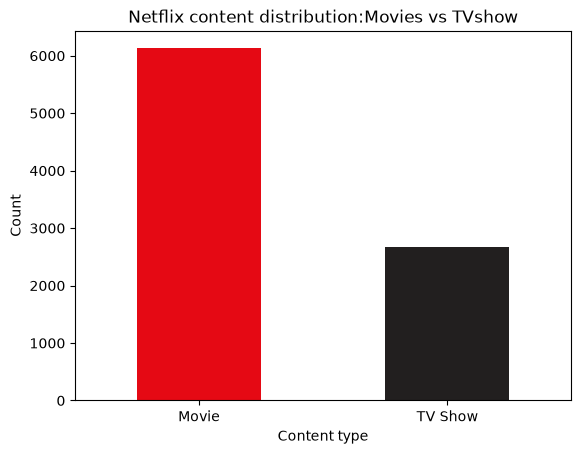

In [ ]:
#Visualize data
import matplotlib .pyplot as plt
df['type'].value_counts().plot(kind='bar', color=['#E50914', '#221f1f'])
plt.title('Netflix content distribution:Movies vs TVshow')
plt.xlabel('Content type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

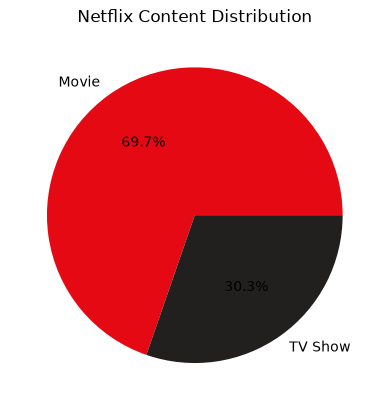

In [34]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#E50914', '#221f1f'])
plt.title('Netflix Content Distribution')
plt.ylabel('')
plt.show()

In [35]:
df['type'].value_counts(normalize=True) * 100

type
Movie      69.692833
TV Show    30.307167
Name: proportion, dtype: float64

In [ ]:
## Key Summary and findings:
#This dataset showed that Netflix prioritized Movies(69%) than TV shows(30.3%)

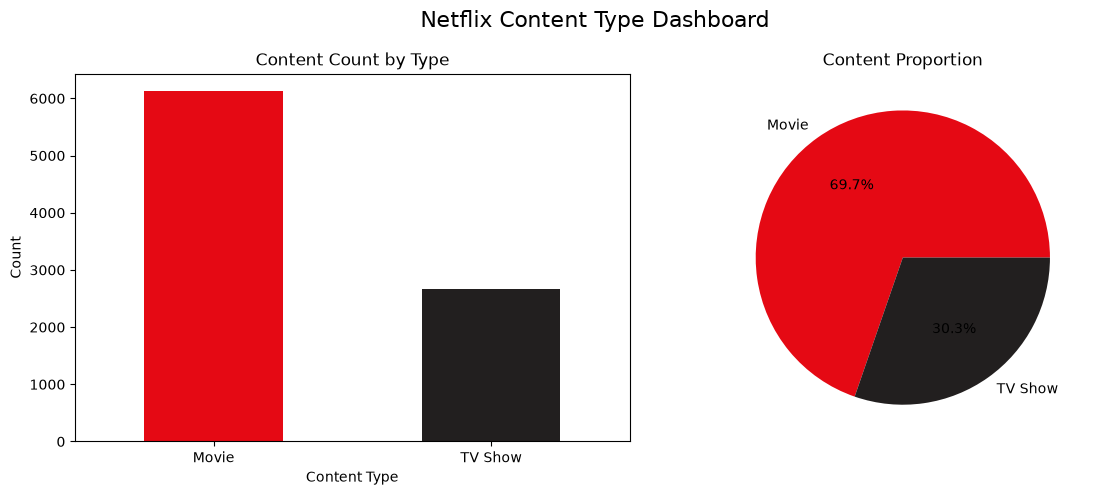

In [36]:
import matplotlib.pyplot as plt

# Create a figure with 1 row, 2 columns (2 charts side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Bar chart (goes in the first slot)
df['type'].value_counts().plot(kind='bar', color=['#E50914', '#221f1f'], ax=axes[0])
axes[0].set_title('Content Count by Type')
axes[0].set_xlabel('Content Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2: Pie chart (goes in the second slot)
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#E50914', '#221f1f'], ax=axes[1])
axes[1].set_title('Content Proportion')
axes[1].set_ylabel('')

plt.suptitle('Netflix Content Type Dashboard', fontsize=16)
plt.tight_layout()
plt.show()

In [40]:
df['country'].str.contains(',').sum()

np.int64(0)

In [41]:
df['country'].value_counts()

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
                  ... 
Luxembourg           1
Senegal              1
Belarus              1
Puerto Rico          1
Cyprus               1
Name: count, Length: 86, dtype: int64

In [42]:
top_countries= df['country'].value_counts().head(10)
top_countries

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

In [43]:
top_countries = df[df['country'] != 'Not Given']['country'].value_counts().head(10)
top_countries

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Mexico             138
Name: count, dtype: int64

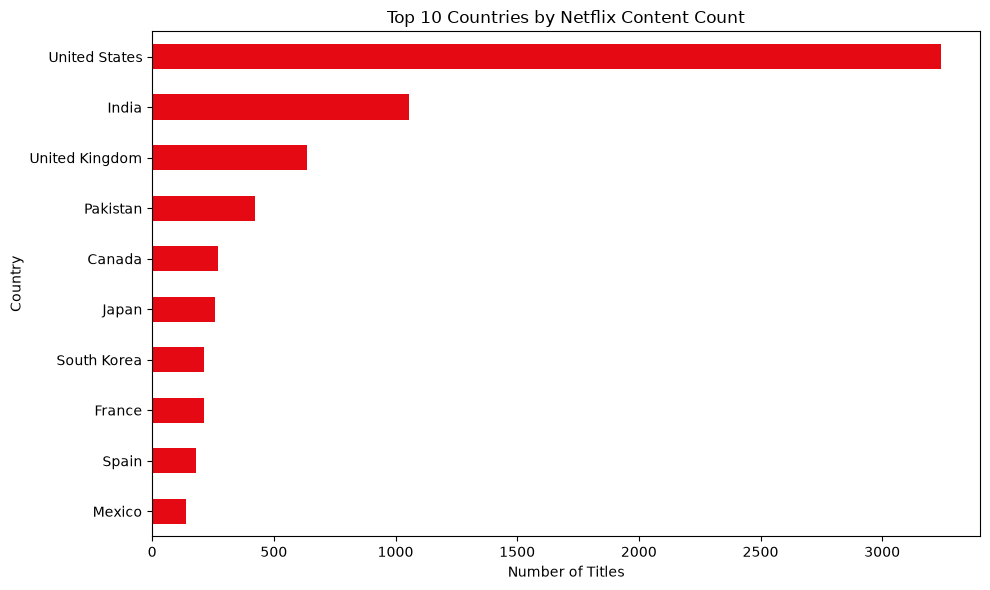

In [44]:
top_countries.sort_values().plot(kind='barh', color='#E50914', figsize=(10, 6))
plt.title('Top 10 Countries by Netflix Content Count')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [45]:
#Ratio of US VS India
3240/1057

3.065279091769158

In [46]:
top_countries.sum() / df[df['country'] != 'Not Given'].shape[0] * 100

np.float64(78.00776196636481)

In [47]:
287 / df.shape[0] * 100

3.2650739476678043

In [ ]:
#Key summary and findings-Country-wise Content Analysis
#The United states takes up 3.1x more content than the second Largest, India.
# It also appears from this dataset that Netflix's catalogue is concentrating on a small number of large production markets like the English speaking market (US,UK,Canada) and South Asian markets(India, Pakistan)as they make up the bulk of the top 10.
## 3.27% of all titles(287 out of 8970) have no recorded country of origin and this is a data quality gap worth flagging for future reporting.
#Business implication: Underrepresented regions should be investigated as potential areas for growth in areas such as content localization or acquistion 

In [49]:
#Task 4
df['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

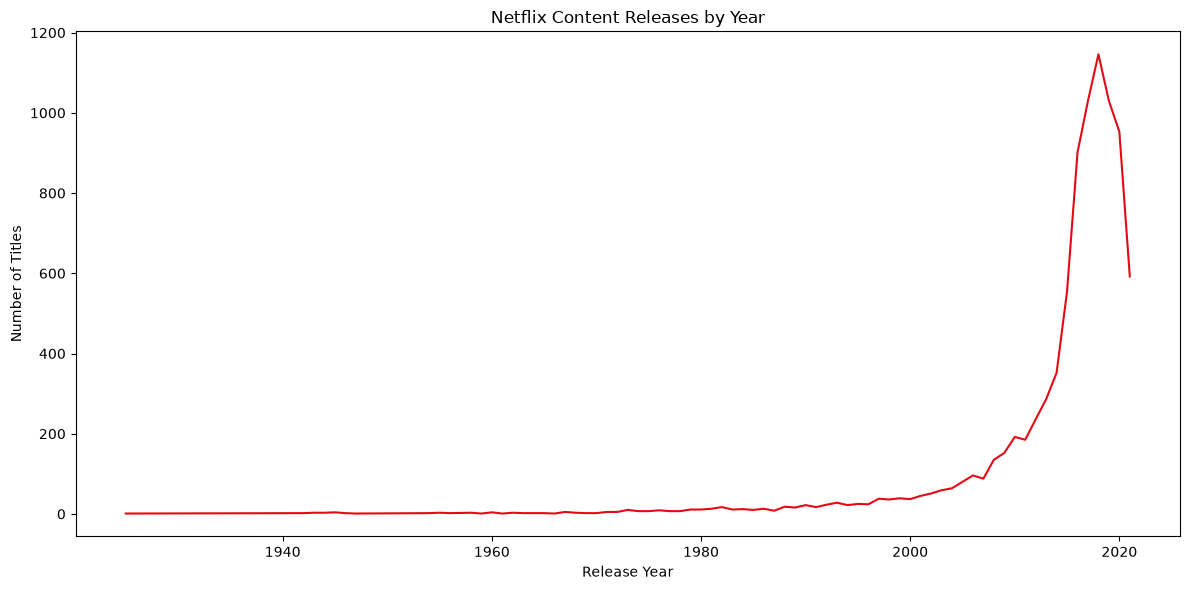

In [50]:
import matplotlib.pyplot as plt

df['release_year'].value_counts().sort_index().plot(kind='line', color='#E50914', figsize=(12, 6))
plt.title('Netflix Content Releases by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

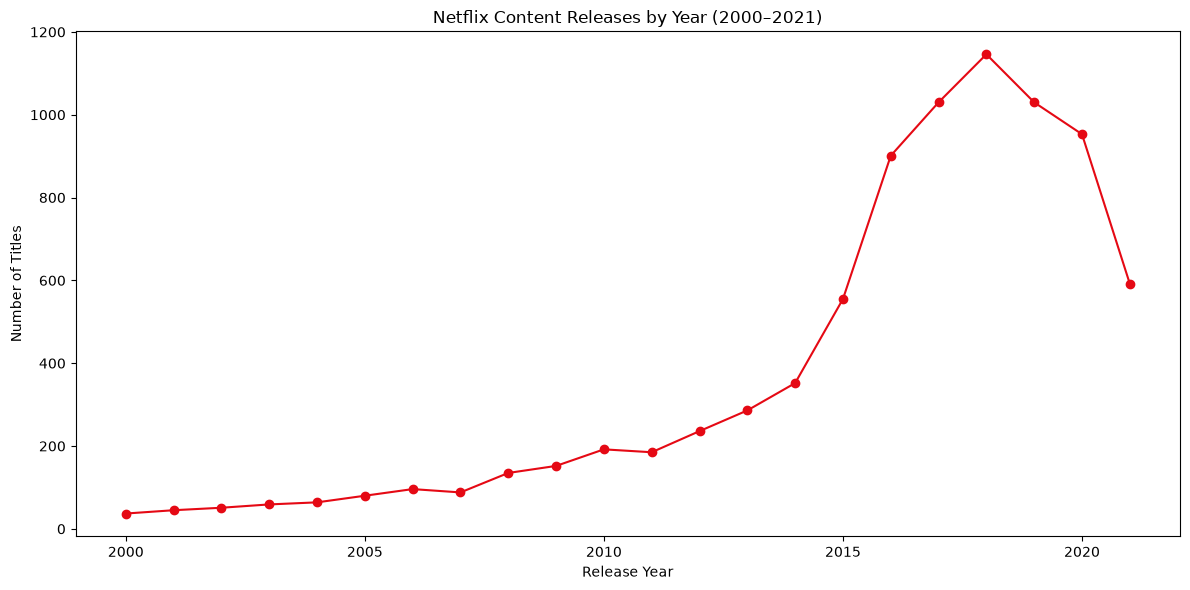

In [51]:
recent = df[df['release_year'] >= 2000]
recent['release_year'].value_counts().sort_index().plot(kind='line', color='#E50914', figsize=(12, 6), marker='o')
plt.title('Netflix Content Releases by Year (2000–2021)')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

In [52]:
df['release_year'].max()

np.int64(2021)

In [ ]:
## Key Findings -Trend Analysis by release year
#Content releases were negligible before 2000. This means that Netflix's catalogue is dominated by contemporary content rather than historical archive.
#Releases trippled from 335 titles in 2014 to a peak of 1146 titles in 2018.
#2018 represents the platform's peak content output year in this dataset.
#There appears to be a decline from 2018 through 2021.however , since 2021 is the most recent year in the present datase, this drop might be an artificial representation which reflects an incomplete/partial year of data ratehr than a geniune downward trend. This should be verified against data collection date before drawing conclusions.
#Business implication: The post-2018 slowdown warrants further investigation. A more complete and recent dataset is recommended before concluding whether it reflects a genuine strategic shift or simply incomplete data for tail-end years.
#2015-2018 represents a surge and all the measures taken such as increased content investment or production should be investigated and replicated.